# IntroExt Personality Classifier - Exploratory Data Analysis

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

## Load data

In [2]:
df = pd.read_csv("../data/personality_dataset.csv")

In [3]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


## Shape of the data

In [4]:
df.shape

(2900, 8)

## Exploring Data Types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


## Descriptive Statistics

In [6]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [7]:
df.describe(include="all")

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,2837.000000,2827,2838.000000,2834.000000,2848,2823.000000,2835.000000,2900
unique,NaN,2,NaN,NaN,2,NaN,NaN,2
top,NaN,No,NaN,NaN,No,NaN,NaN,Extrovert
freq,NaN,1417,NaN,NaN,1441,NaN,NaN,1491
mean,4.505816,NaN,3.963354,3.000000,NaN,6.268863,3.564727,NaN
std,3.479192,NaN,2.903827,2.247327,NaN,4.289693,2.926582,NaN
min,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,2.000000,NaN,2.000000,1.000000,NaN,3.000000,1.000000,NaN
50%,4.000000,NaN,3.000000,3.000000,NaN,5.000000,3.000000,NaN
75%,8.000000,NaN,6.000000,5.000000,NaN,10.000000,6.000000,NaN


## Exploring Missing Values

In [8]:
df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

## Exploring Duplicate values

In [9]:
df.duplicated().sum()

np.int64(388)

In [10]:
df = df.drop_duplicates()
df.shape

(2512, 8)

## Identifying Categorical and Numerical Variables

In [11]:
categorical_df = df.select_dtypes(include=["object"])
categorical_df.head()

C:\Users\sanid\AppData\Local\Temp\ipykernel_31488\3412186585.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = df.select_dtypes(include=["object"])


,Stage_fear,Drained_after_socializing,Personality
0,No,No,Extrovert
1,Yes,Yes,Introvert
2,Yes,Yes,Introvert
3,No,No,Extrovert
4,No,No,Extrovert


In [12]:
numerical_df = df.select_dtypes(include='number')
numerical_df.head()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
0,4.0,4.0,6.0,13.0,5.0
1,9.0,0.0,0.0,0.0,3.0
2,9.0,1.0,2.0,5.0,2.0
3,0.0,6.0,7.0,14.0,8.0
4,3.0,9.0,4.0,8.0,5.0


## Exploring Categorical Variables

### Distribution of Categorical Variables

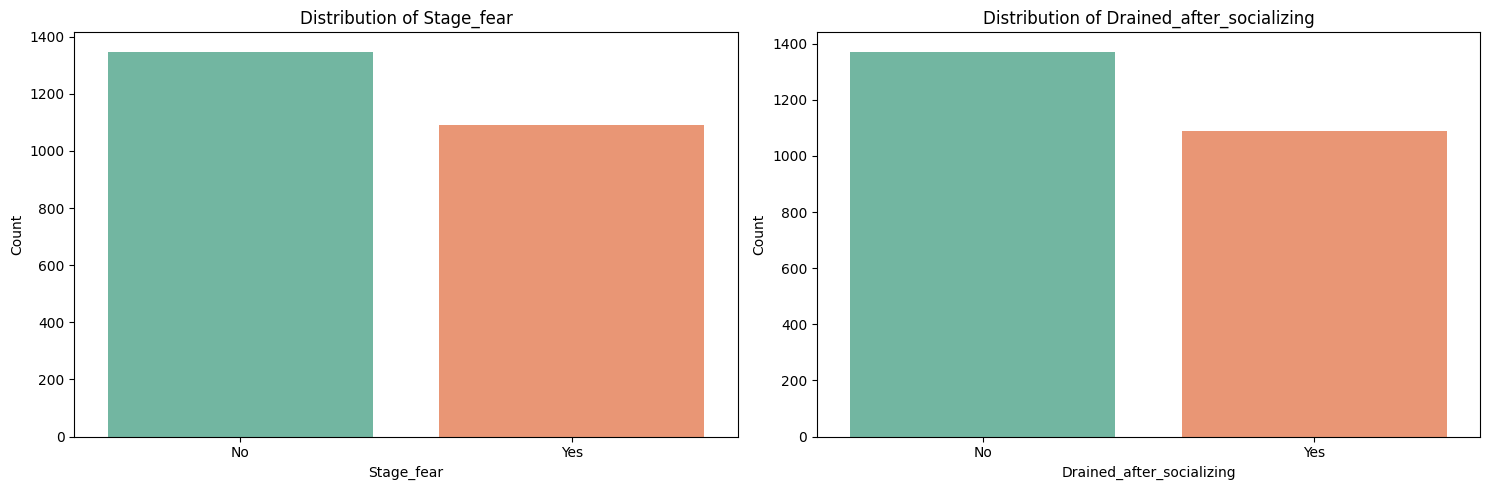

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(categorical_df[["Stage_fear", "Drained_after_socializing"]]):
    sns.countplot(x=col, data=categorical_df, palette="Set2", ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Distribution of categorical features against the target

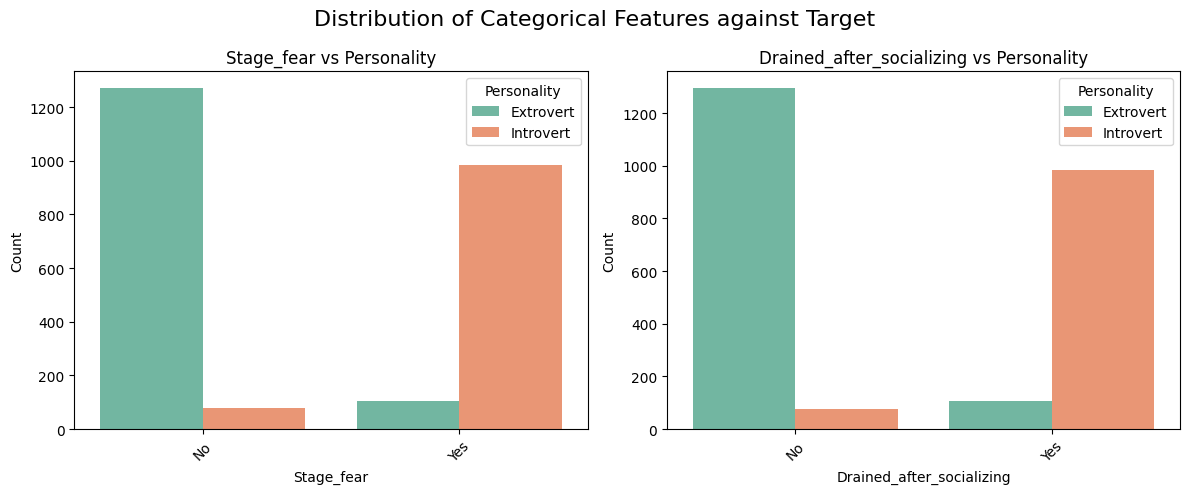

In [14]:
cat_cols = [col for col in categorical_df.columns if col != 'Personality']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Personality', data=df, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col} vs Personality")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Personality', loc='upper right')

plt.suptitle("Distribution of Categorical Features against Target", fontsize=16)
plt.tight_layout()
plt.show()

## Exploring numerical features

### Distribution of numerical features

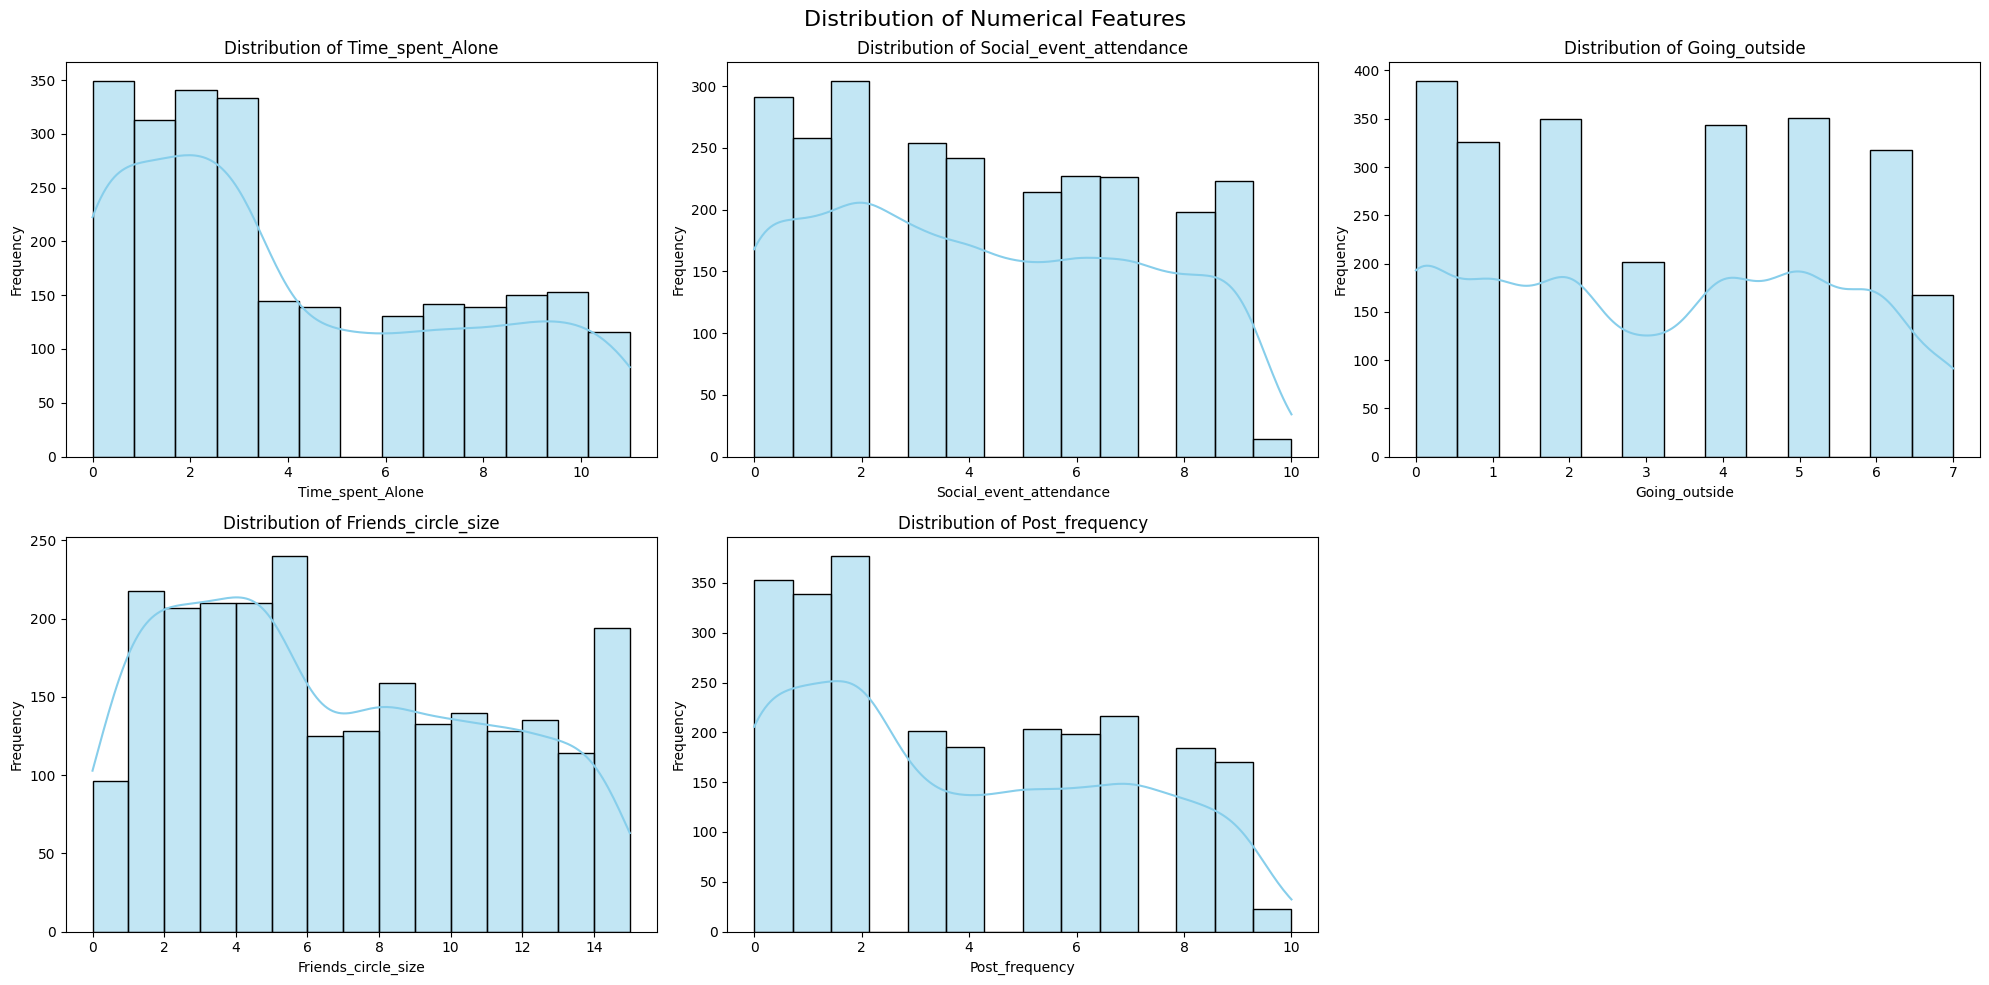

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_df.columns):
    sns.histplot(numerical_df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Distribution of numerical features against the target

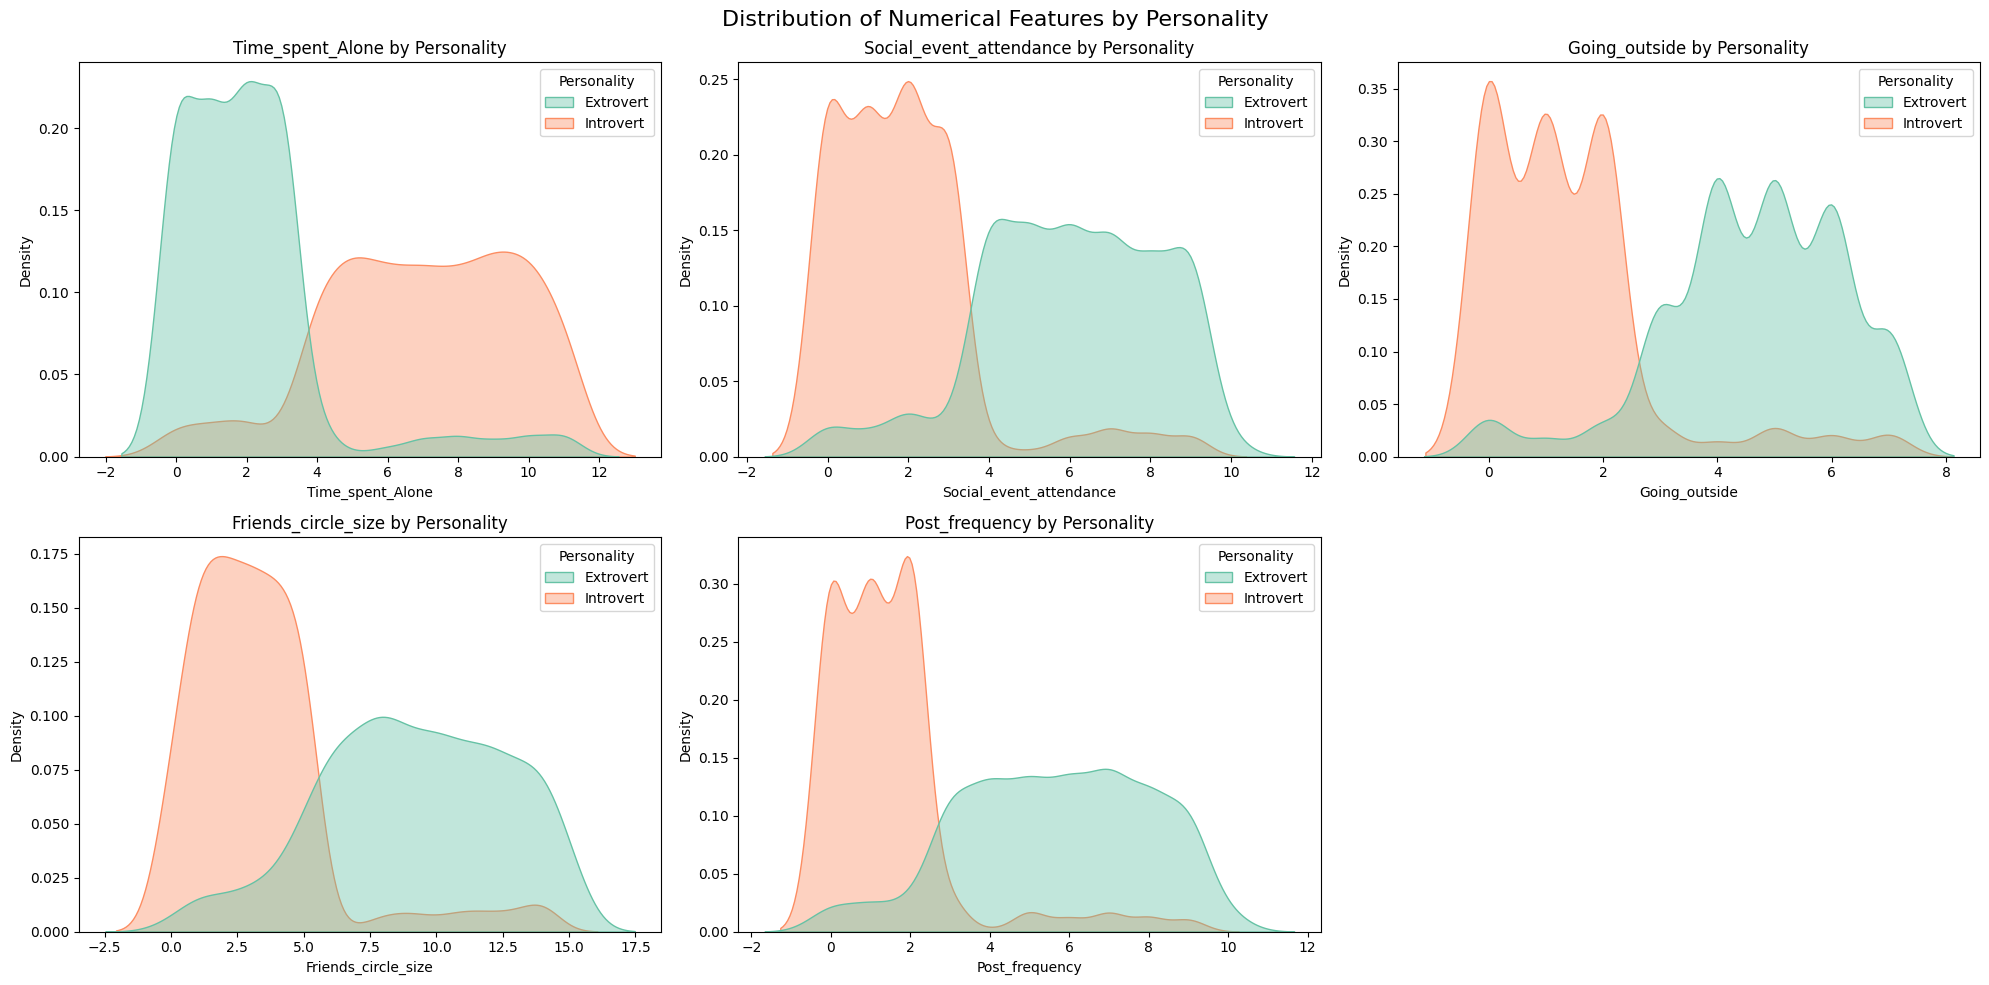

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_df.columns):
    sns.kdeplot(data=df, x=col, hue='Personality', fill=True, common_norm=False, alpha=0.4, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} by Personality")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Numerical Features by Personality", fontsize=16)
plt.tight_layout()
plt.show()

### Boxplots of numerical features

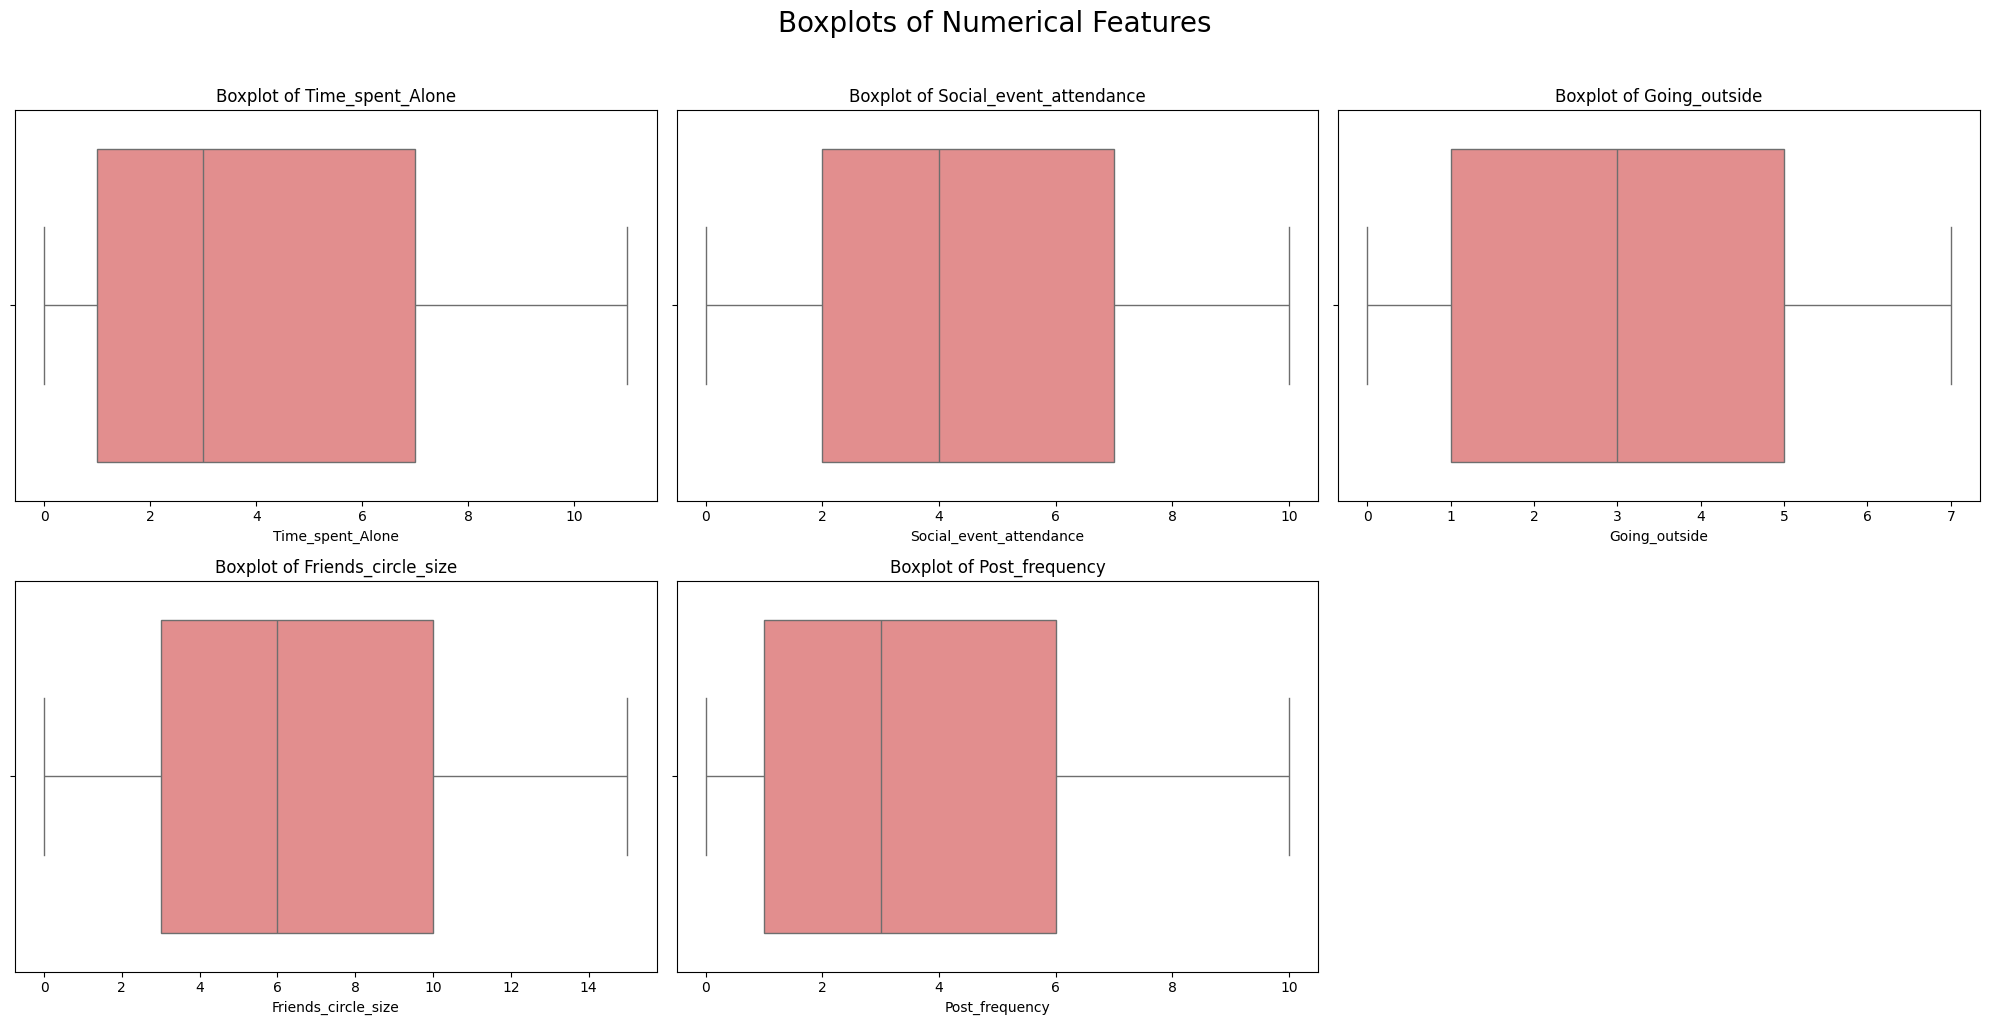

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_df.columns):
    sns.boxplot(x=numerical_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots of Numerical Features", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

### Exploring correlations of Numeric features

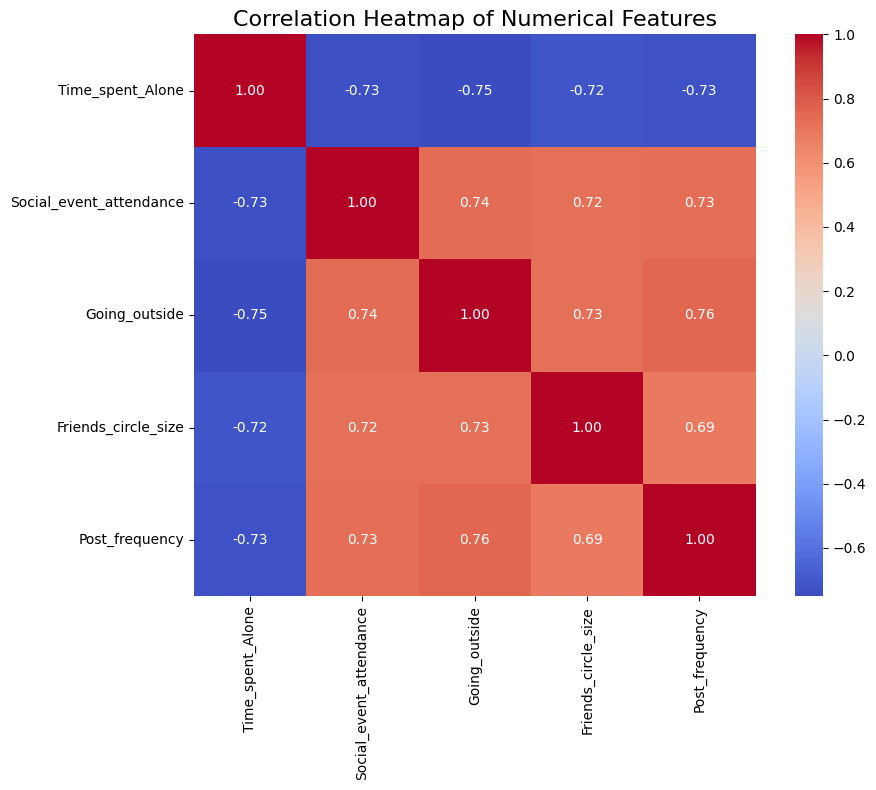

In [18]:
corr = df[numerical_df.columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## Detecting outliers

In [19]:
summary = []

for col in numerical_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_percentage = round(100 * outlier_mask.mean(), 2)

    summary.append([col, lower_bound, upper_bound, outlier_count, outlier_percentage])

outlier_summary = pd.DataFrame(summary, columns=['Feature', 'Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier Percentage'])
outlier_summary

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Time_spent_Alone,-8.0,16.0,0,0.0
1,Social_event_attendance,-5.5,14.5,0,0.0
2,Going_outside,-5.0,11.0,0,0.0
3,Friends_circle_size,-7.5,20.5,0,0.0
4,Post_frequency,-6.5,13.5,0,0.0


## Target Variable Distribution

In [20]:
df["Personality"].value_counts()

Personality
Extrovert    1417
Introvert    1095
Name: count, dtype: int64

Text(0, 0.5, 'Count')

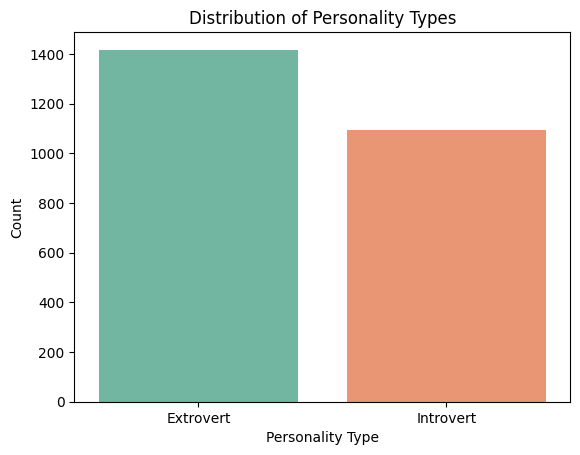

In [21]:
sns.countplot(x="Personality", data=df, palette="Set2", hue="Personality", legend=False)
plt.title("Distribution of Personality Types")
plt.xlabel("Personality Type") 
plt.ylabel("Count")

## Summary of Findings

**Dataset Quality and Structure**
- The dataset contains 2900 personalities with 8 features. 
- Missing values were found and should be addressed in model development feature engineering
- 388 duplicates were found and removed, making the dataset reduce to 2512 records
- Outlier analysis confirmed that numerical features are well behaved with no extreme values outside IQR bounds

**Target Distribution**
- Slightly imbalanced dataset with extrovert ~56.4% and introverts being 43.6%

**Categorical Insights**
- Both `Stage_fear` and `Drained_after_socializing` show near-identical distributions against the target
- Extroverts overwhelmingly respond No to both, while Introverts overwhelmingly respond Yes
- These two features are strong binary indicators of personality type

**Numerical Insights**
- All numerical features show clear separation between Introvert and Extrovert distributions
- Introverts cluster at **lower values** for `Social_event_attendance`, `Going_outside`, 
  `Friends_circle_size`, and `Post_frequency`
- `Time_spent_Alone` is the inverse — Introverts cluster at **higher values**
- This confirms all 5 numerical features are strong predictors of personality type

**Correlation Insights**
- `Time_spent_Alone` is strongly negatively correlated with all social features (~-0.72 to -0.75)
- All social features (`Social_event_attendance`, `Going_outside`, `Friends_circle_size`, 
  `Post_frequency`) are moderately positively correlated with each other (0.69 - 0.76)
- Multicollinearity is present but does not affect tree-based models such as Random Forest and XGBoost

# Data Preprocessing

## Handling Missing Values

In [22]:
df.isnull().sum()

Time_spent_Alone             61
Stage_fear                   73
Social_event_attendance      61
Going_outside                65
Drained_after_socializing    51
Friends_circle_size          75
Post_frequency               63
Personality                   0
dtype: int64

### Replace with median for numeric features

In [23]:
numerical_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [24]:
df.isnull().sum()

Time_spent_Alone              0
Stage_fear                   73
Social_event_attendance       0
Going_outside                 0
Drained_after_socializing    51
Friends_circle_size           0
Post_frequency                0
Personality                   0
dtype: int64

In [25]:
print(df[df['Stage_fear'].isnull()]['Personality'].value_counts())
print(df[df['Drained_after_socializing'].isnull()]['Personality'].value_counts())

Personality
Extrovert    42
Introvert    31
Name: count, dtype: int64
Personality
Introvert    33
Extrovert    18
Name: count, dtype: int64


### Handling categorical missing values with random sampling

In [26]:
categorical_cols = ['Stage_fear', 'Drained_after_socializing']

for col in categorical_cols:
    null_count = df[col].isnull().sum()
    fill_values = df[col].dropna().sample(null_count, random_state=42).values
    df.loc[df[col].isnull(), col] = fill_values

In [27]:
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

## Feature Encoding

### Encoding target variable

In [28]:
df["Personality"] = df["Personality"].map({'Introvert': 0, 'Extrovert': 1})

### Encoding categorical variables

In [29]:
df["Stage_fear"] = df["Stage_fear"].map({'Yes': 1, 'No': 0})
df["Drained_after_socializing"] = df["Drained_after_socializing"].map({'Yes': 1, 'No': 0})

In [30]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,1
1,9.0,1,0.0,0.0,1,0.0,3.0,0
2,9.0,1,1.0,2.0,1,5.0,2.0,0
3,0.0,0,6.0,7.0,0,14.0,8.0,1
4,3.0,0,9.0,4.0,0,8.0,5.0,1


In [31]:
df.dtypes

Time_spent_Alone             float64
Stage_fear                     int64
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing      int64
Friends_circle_size          float64
Post_frequency               float64
Personality                    int64
dtype: object

## Train Test Split

### Split target variable 

In [32]:
X = df.drop("Personality", axis=1)
y = df["Personality"]

### Split the data

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2009, 7)
X_test: (503, 7)
y_train: (2009,)
y_test: (503,)


## Save the preprocessed dataset 

In [36]:
df.to_csv("../data/personality_dataset_cleaned.csv", index=False)